In [61]:
import pandas as pd

df = pd.read_csv("Filtrado3.csv") 


In [62]:
df.head()

,gid,Denominació / Denominación,Estat / Estado,geo_point_2d,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo),fecha,hora
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,"39.46968578972779,-0.4059148701576997",7,3,De 4 a 3,3 (Entrada),NaN,2023-01-01,00:00:00
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,"39.47049109929769,-0.37811268049966074",FUERA,FUERA,FUERA,FUERA,FUERA,2023-01-01,00:00:00
2,1954,MENORCA HACIA AV. DEL PUERTO,0,"39.458985865466786,-0.34290002968190025",12,13,4,NaN,Antihorario,2023-01-01,00:00:00
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,"39.465406595904575,-0.33589367082315114",12/13,13,4,NaN,Antihorario,2023-01-01,00:00:00
4,1939,PASO ELEVADO HACIA GIORGETA,0,"39.45605895949036,-0.37983857646201424",2/10,3/8/9,3,NaN,Horario,2023-01-01,00:00:00


In [63]:
import pandas as pd

pd.set_option('display.max_rows', None)

print(df["hora"].value_counts())

hora
22:15:00    121655
00:45:00    121510
01:15:00    121510
01:30:00    121365
14:00:00    121365
22:45:00    121365
21:45:00    121365
19:15:00    121365
21:15:00    121365
00:30:00    121365
22:30:00    121365
23:30:00    121276
15:30:00    121220
01:45:00    121220
14:30:00    121220
19:45:00    121220
22:00:00    121220
16:15:00    121075
15:15:00    121075
18:15:00    121075
11:45:00    121075
11:30:00    121075
14:45:00    121075
00:15:00    121075
06:45:00    121075
07:15:00    121075
03:30:00    121075
03:15:00    121075
17:15:00    121075
17:30:00    121075
18:45:00    121075
20:45:00    121075
20:15:00    121075
23:15:00    121075
23:45:00    121075
13:45:00    120930
20:00:00    120930
19:30:00    120930
15:45:00    120930
21:30:00    120930
17:45:00    120930
16:45:00    120930
16:30:00    120930
20:30:00    120930
04:15:00    120930
03:00:00    120930
01:00:00    120930
06:15:00    120930
08:15:00    120785
03:45:00    120785
15:00:00    120785
18:30:00    120785
10:15:0

In [64]:
df["hora_15"] = (
    pd.to_datetime(df["hora"].astype(str), format="%H:%M:%S", errors="coerce")
    .dt.round("15min")
    .dt.strftime("%H:%M:%S")
)

In [65]:
pd.set_option('display.max_rows', None)

print(df["hora_15"].value_counts())

hora_15
22:15:00    121655
00:45:00    121510
22:00:00    121510
01:15:00    121510
01:45:00    121365
14:00:00    121365
01:30:00    121365
00:30:00    121365
21:15:00    121365
22:45:00    121365
19:15:00    121365
21:45:00    121365
22:30:00    121365
23:30:00    121276
14:30:00    121220
01:00:00    121220
19:45:00    121220
15:30:00    121220
16:15:00    121220
11:30:00    121075
11:45:00    121075
14:45:00    121075
00:15:00    121075
03:30:00    121075
03:15:00    121075
07:15:00    121075
06:45:00    121075
17:15:00    121075
18:45:00    121075
18:15:00    121075
17:30:00    121075
19:30:00    121075
21:30:00    121075
23:45:00    121075
23:15:00    121075
20:45:00    121075
15:45:00    121075
20:15:00    121075
15:15:00    121075
17:45:00    120930
20:00:00    120930
20:30:00    120930
18:30:00    120930
16:30:00    120930
13:15:00    120930
13:45:00    120930
10:15:00    120930
15:00:00    120930
03:00:00    120930
16:45:00    120930
04:15:00    120930
06:15:00    120930
08:1

In [66]:
df["fecha_hora"] = pd.to_datetime(df["fecha"].astype(str) + " " + df["hora"].astype(str))
df["hora_15"] = (
    pd.to_datetime(df["hora"].astype(str), format="%H:%M:%S", errors="coerce")
    .dt.round("15min")
    .dt.strftime("%H:%M:%S")
)

conteo = df.groupby(["fecha", "hora_15"]).size().unstack(fill_value=0)
print(conteo)

hora_15     00:00:00  00:15:00  00:30:00  00:45:00  01:00:00  01:15:00  \
fecha                                                                    
2022-12-01         0         0         0         0         0         0   
2022-12-02       145       145       145       145       145       145   
2022-12-03       145       145       145       145       145       145   
2022-12-04       145       145       145       145       145       145   
2022-12-05       145       145       145       145       145       145   
2022-12-06       145       145       145       145       145       145   
2022-12-07       145       145       145       145       145       145   
2022-12-08       145       145       145       145       145       145   
2022-12-09       145       145       145       145       145       145   
2022-12-10       145       145       145       145       145       145   
2022-12-11       145       145       145       145       145       145   
2022-12-12       145       145       1

In [67]:
print(df.columns)

Index(['gid', 'Denominació / Denominación', 'Estat / Estado', 'geo_point_2d',
       'Distritos (pertenece)', 'Distritos (se dirige)', 'Anillos',
       'Salidas/Entrada', 'Direccion (Solo intraanillo)', 'fecha', 'hora',
       'hora_15', 'fecha_hora'],
      dtype='object')


In [68]:
import pandas as pd

# Asegurar que hora_15 está en formato hora
df["hora_15"] = pd.to_datetime(df["hora_15"].astype(str), format="%H:%M:%S", errors="coerce").dt.time

# Filtrar entre 01:00 y 06:00 usando hora_15
df_madrugada = df[
    (df["hora_15"] >= pd.to_datetime("01:00:00").time()) &
    (df["hora_15"] <=  pd.to_datetime("06:00:00").time())
]

# Filtrar estados atípicos: distintos de 0, 4, 5, 9
df_atipicos = df_madrugada[
    ~df_madrugada["Estat / Estado"].isin([0, 3, 4, 5, 8, 9])
]

# Preparar salida parecida a tu captura
resultado = (
    df_atipicos[
        ["fecha", "hora_15", "Denominació / Denominación", "Estat / Estado"]
    ]
    .drop_duplicates()
    .sort_values(["fecha", "hora_15"])
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print(f"Total de registros entre 01:00 y 06:00 con estado anómalo: {len(resultado)}\n")
print(resultado.to_string(index=False))

Total de registros entre 01:00 y 06:00 con estado anómalo: 397

     fecha  hora_15                                       Denominació / Denominación  Estat / Estado
2022-12-11 01:45:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2
2022-12-11 02:00:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2
2022-12-11 02:15:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2
2022-12-11 02:30:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               2
2022-12-31 01:00:00                                      PASO ELEVADO HACIA GIORGETA               1
2023-02-17 06:00:00                         PRIMADO REIG (DE CATALUÑA A EMILIO BARÓ)               1
2023-02-26 01:15:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               1
2023-02-26 01:30:00                    CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)               1
2023-02-26 01:45:00        

In [69]:
total_atipicos = len(df[~df["Estat / Estado"].isin([0, 3, 4, 5, 8, 9])])

print("Total de registros atípicos (todas las horas):", total_atipicos)

Total de registros atípicos (todas las horas): 48389


In [70]:
df["Estat / Estado"].value_counts()

Estat / Estado
0    10501142
5      940108
4       60015
3       38142
1       36621
6        5689
8        5181
2        4996
7        1083
9         174
Name: count, dtype: int64

In [71]:
map_estado_reducido = {
    0: 0, 5: 0,   # Fluido
    1: 1, 6: 1,   # Denso
    2: 2, 7: 2,   # Congestionado
    3: 3, 8: 3,   # Cortado
    4: 4, 9: 4    # Sin datos
}

df["Estado_reducido"] = df["Estat / Estado"].map(map_estado_reducido)

In [72]:
df["Estado_reducido"].value_counts()

Estado_reducido
0    11441250
4       60189
3       43323
1       42310
2        6079
Name: count, dtype: int64

In [73]:
df.head()

,gid,Denominació / Denominación,Estat / Estado,geo_point_2d,Distritos (pertenece),Distritos (se dirige),Anillos,Salidas/Entrada,Direccion (Solo intraanillo),fecha,hora,hora_15,fecha_hora,Estado_reducido
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,5,"39.46968578972779,-0.4059148701576997",7,3,De 4 a 3,3 (Entrada),NaN,2023-01-01,00:00:00,00:00:00,2023-01-01,0
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),0,"39.47049109929769,-0.37811268049966074",FUERA,FUERA,FUERA,FUERA,FUERA,2023-01-01,00:00:00,00:00:00,2023-01-01,0
2,1954,MENORCA HACIA AV. DEL PUERTO,0,"39.458985865466786,-0.34290002968190025",12,13,4,NaN,Antihorario,2023-01-01,00:00:00,00:00:00,2023-01-01,0
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,0,"39.465406595904575,-0.33589367082315114",12/13,13,4,NaN,Antihorario,2023-01-01,00:00:00,00:00:00,2023-01-01,0
4,1939,PASO ELEVADO HACIA GIORGETA,0,"39.45605895949036,-0.37983857646201424",2/10,3/8/9,3,NaN,Horario,2023-01-01,00:00:00,00:00:00,2023-01-01,0


In [74]:
cols_eliminar = ["Estat / Estado", "geo_point_2d", "hora", "fecha_hora", 'Distritos (pertenece)', 'Distritos (se dirige)', 'Anillos',
       'Salidas/Entrada', 'Direccion (Solo intraanillo)']
df = df.drop(columns=[c for c in cols_eliminar if c in df.columns])

In [75]:
print(len(df["fecha"].unique()))

854


In [76]:
df.head()

,gid,Denominació / Denominación,fecha,hora_15,Estado_reducido
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,2023-01-01,00:00:00,0
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),2023-01-01,00:00:00,0
2,1954,MENORCA HACIA AV. DEL PUERTO,2023-01-01,00:00:00,0
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,2023-01-01,00:00:00,0
4,1939,PASO ELEVADO HACIA GIORGETA,2023-01-01,00:00:00,0


In [77]:
df = df.rename(columns={
    "hora_15" : "hora",
    "Estado_reducido" : "Estado"
})

In [78]:
df.head()

,gid,Denominació / Denominación,fecha,hora,Estado
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,2023-01-01,00:00:00,0
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),2023-01-01,00:00:00,0
2,1954,MENORCA HACIA AV. DEL PUERTO,2023-01-01,00:00:00,0
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,2023-01-01,00:00:00,0
4,1939,PASO ELEVADO HACIA GIORGETA,2023-01-01,00:00:00,0


In [79]:
hora_dt = pd.to_datetime(df["hora"], format="%H:%M:%S")

df = df[
    ~(
        (hora_dt.dt.hour >= 1) & 
        (hora_dt.dt.hour < 6) & 
        ~((hora_dt.dt.hour == 1) & (hora_dt.dt.minute == 0))
    )
]

df["hora"].value_counts().sort_index()

hora
00:00:00    119190
00:15:00    121075
00:30:00    121365
00:45:00    121510
01:00:00    121220
06:00:00    120350
06:15:00    120930
06:30:00    120640
06:45:00    121075
07:00:00    120350
07:15:00    121075
07:30:00    120640
07:45:00    120060
08:00:00    120060
08:15:00    120785
08:30:00    119915
08:45:00    120495
09:00:00    120205
09:15:00    120495
09:30:00    120640
09:45:00    120205
10:00:00    120785
10:15:00    120930
10:30:00    120640
10:45:00    120495
11:00:00    120060
11:15:00    120785
11:30:00    121075
11:45:00    121075
12:00:00    120785
12:15:00    119770
12:30:00    120205
12:45:00    120350
13:00:00    120060
13:15:00    120930
13:30:00    120205
13:45:00    120930
14:00:00    121365
14:15:00    120785
14:30:00    121220
14:45:00    121075
15:00:00    120930
15:15:00    121075
15:30:00    121220
15:45:00    121075
16:00:00    120640
16:15:00    121220
16:30:00    120930
16:45:00    120930
17:00:00    120785
17:15:00    121075
17:30:00    121075
17:45:0

In [80]:
print(len(df["Denominació / Denominación"]))

9302241


In [81]:
print(df.dtypes)

gid                            int64
Denominació / Denominación    object
fecha                         object
hora                          object
Estado                         int64
dtype: object


In [82]:
# Denominación como texto
df["Denominació / Denominación"] = df["Denominació / Denominación"].astype(str)

# Fecha como datetime (fecha)
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Hora como texto
df["hora"] = df["hora"].astype(str)

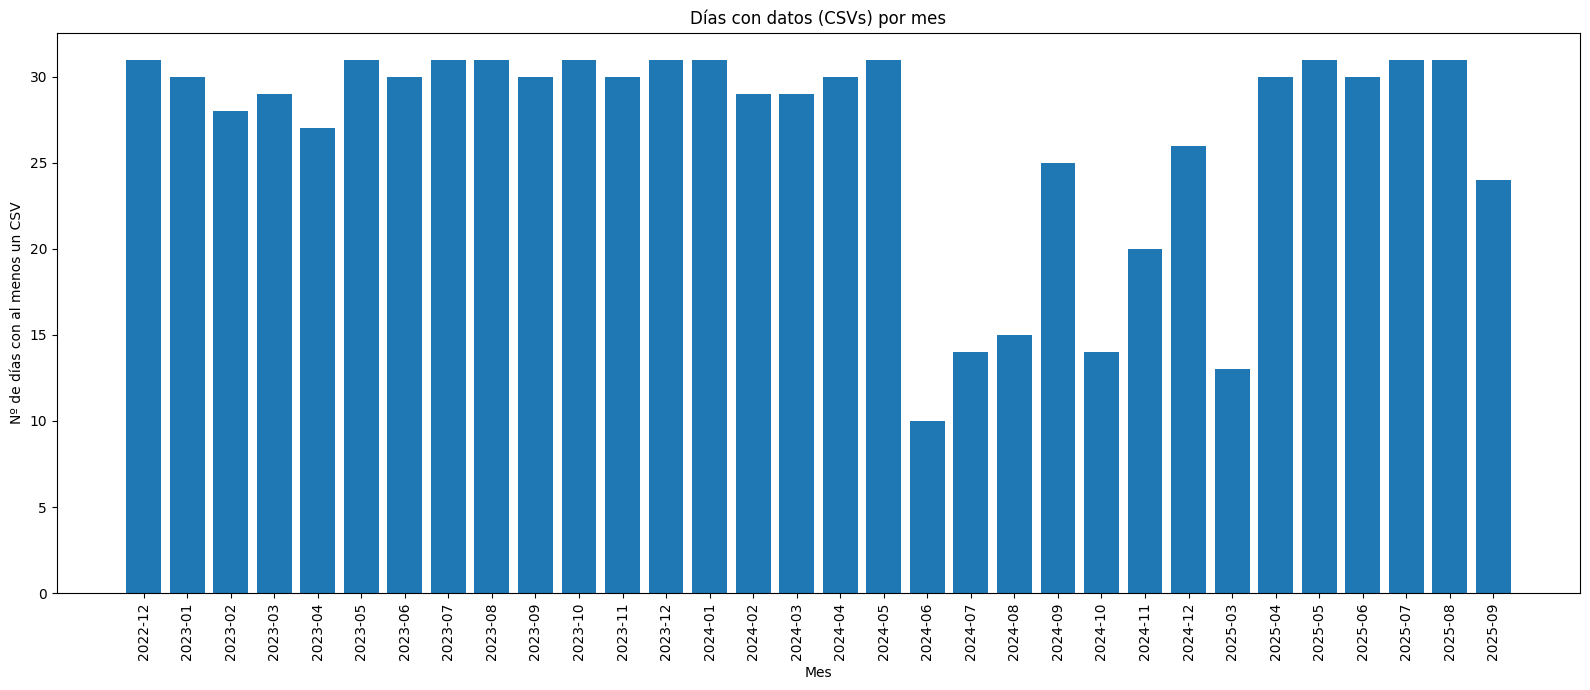

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar tipo fecha
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Crear mes
df["mes"] = df["fecha"].dt.to_period("M").astype(str)

# Contar días únicos por mes
dias_por_mes = df.groupby("mes")["fecha"].apply(lambda x: x.dt.date.nunique())

# Graficar
plt.figure(figsize=(16, 7))
plt.bar(dias_por_mes.index, dias_por_mes.values)

plt.title("Días con datos (CSVs) por mes")
plt.xlabel("Mes")
plt.ylabel("Nº de días con al menos un CSV")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [84]:
df.head()

,gid,Denominació / Denominación,fecha,hora,Estado,mes
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,2023-01-01,00:00:00,0,2023-01
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),2023-01-01,00:00:00,0,2023-01
2,1954,MENORCA HACIA AV. DEL PUERTO,2023-01-01,00:00:00,0,2023-01
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,2023-01-01,00:00:00,0,2023-01
4,1939,PASO ELEVADO HACIA GIORGETA,2023-01-01,00:00:00,0,2023-01


In [85]:
df = df.drop(columns=["mes"])

In [86]:
df.head()

,gid,Denominació / Denominación,fecha,hora,Estado
0,2167,PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS,2023-01-01,00:00:00,0
1,1987,SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA),2023-01-01,00:00:00,0
2,1954,MENORCA HACIA AV. DEL PUERTO,2023-01-01,00:00:00,0
3,1955,SERRERIA HACIA BLASCO IBAÑEZ,2023-01-01,00:00:00,0
4,1939,PASO ELEVADO HACIA GIORGETA,2023-01-01,00:00:00,0


In [87]:
print(df["Denominació / Denominación"].value_counts())

Denominació / Denominación
PASO ELEVADO HACIA GIORGETA                                                    64154
JÁTIVA                                                                         64154
GENERAL AVILÉS (DE M. RODRIGO A PÍO BAROJA)                                    64154
M. CANDELA CAP A AV. DEL PORT                                                  64154
ARAGON CAP A PL. SARAGOSSA                                                     64154
CNO. NUEVO DE PICAÑA HACIA TRES CRUCES                                         64154
AV. DEL CID (DE A-3 A NUEVE DE OCTUBRE)                                        64154
CORTES VALENCIANAS (DE CV-35 A CAMP DE TURIA)                                  64154
PASO INFERIOR AV. DEL CID HACIA A-3                                            64154
A-3 SENTIDO SALIDA                                                             64154
TRES CRUCES (DE TRES FORQUES A ARCHIDUQUE CARLOS)                              64154
PASO INFERIOR CATALUÑA DE SALIDA      

In [89]:
conteo_estado4 = df[df["Estado"] == 4] \
    .groupby("Denominació / Denominación") \
    .size() \
    .sort_values(ascending=False)

print(conteo_estado4)

Denominació / Denominación
PAZ (DE MARQUÉS DE DOS AGUAS A PL. DE LA REINA)                                46546
TRES CRUCES (DE TRES FORQUES A ARCHIDUQUE CARLOS)                                 31
TRES CRUCES (DE CNO. NUEVO DE PICAÑA A GASPAR AGUILAR)                            31
TRES CRUCES (DE ARCHIDUQUE CARLOS A TRES FORQUES)                                 30
TOMAS SALA (DE SAN VICENTE A CARTEROS)                                            30
CNO. NUEVO DE PICAÑA HACIA CV-36                                                  30
TOMAS SALA (DE GASPAR AGUILAR A CARTEROS)                                         30
TRES CRUCES (DE GASPAR AGUILAR A ARCHIDUQUE CARLOS)                               30
FDO. ABRIL MARTORELL (DE MALILLA A AUSIAS MARCH)                                  29
FDO. ABRIL MARTORELL (DE MALILLA A SAN VICENTE)                                   29
TRES FORQUES (DE PÉREZ GALDÓS A TRES CRUCES)                                      28
PASO INFERIOR ANTONIO FERRANDIS HACIA 

<Axes: xlabel='Denominació / Denominación'>

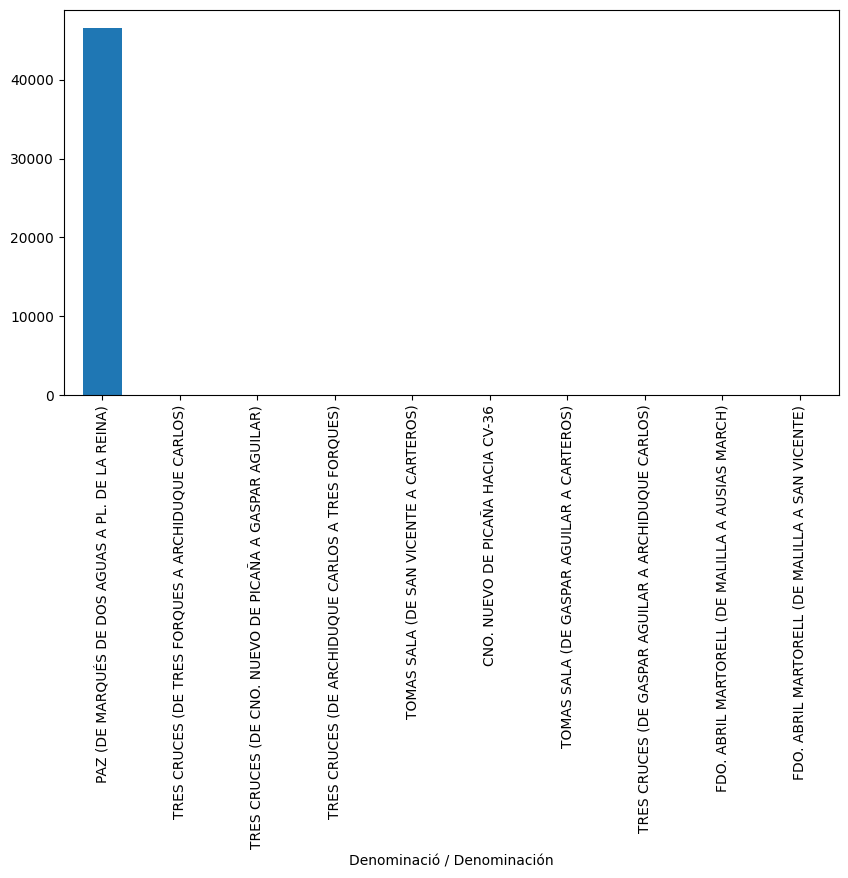

In [90]:
conteo_estado4.head(10).plot(
    kind="bar",
    x="Denominació / Denominación",
    y="num_casos",
    figsize=(10,5)
)

In [91]:
conteo_estado4 = df[df["Estado"] == 3] \
    .groupby("Denominació / Denominación") \
    .size() \
    .sort_values(ascending=False)

print(conteo_estado4)

Denominació / Denominación
GIORGETA CAP A PEREZ GALDOS                                                    6586
PEREZ GALDOS CAP A GIORGETA (SENSE P.I. NI VIA DE SERVICI)                     6049
VÍA DE SERVICIO PASO INFERIOR DE PÉREZ GALDÓS (DE CUENCA A ÁNGEL GUIMERÁ)      3582
PÉREZ GALDÓS HACIA PUENTE CAMPANAR                                             1521
COLÓN                                                                          1201
SAN VICENTE (DE SAN AGUSTIN A MªCRISTINA)                                      1189
PAZ (DE GENERAL TOVAR A MARQUÉS DE DOS AGUAS)                                  1111
JÁTIVA                                                                          807
PASO INFERIOR AV. DEL CID HACIA PÉREZ GALDÓS                                    754
BLANQUERÍAS (DESDE SALIDA DEL PASO INFERIOR A TORRES DE SERRANOS)               611
SAN VICENTE (DE PLAZA DE ESPAÑA A S. AGUSTIN)                                   594
PUENTE DE ARAGÓN HACIA MARQUÉS DEL TURIA         

In [92]:
df["Estado"].value_counts()

Estado
0    9170455
4      48692
1      42041
3      35045
2       6008
Name: count, dtype: int64

In [93]:
print(len(df["Denominació / Denominación"]))

9302241


In [94]:
df = df[
    df["Denominació / Denominación"].str.strip() != 
    "PAZ (DE MARQUÉS DE DOS AGUAS A PL. DE LA REINA)"
]

In [95]:
print((df["Denominació / Denominación"] == 
       "PAZ (DE MARQUÉS DE DOS AGUAS A PL. DE LA REINA)").sum())

0


In [97]:
print(len(df["Denominació / Denominación"]))

9238087


In [98]:
df["Estado"].value_counts()

Estado
0    9152847
1      42041
3      35045
2       6008
4       2146
Name: count, dtype: int64

In [99]:
conteo_estado4 = df[df["Estado"] == 4] \
    .groupby("Denominació / Denominación") \
    .size() \
    .sort_values(ascending=False)

print(conteo_estado4)

Denominació / Denominación
TRES CRUCES (DE CNO. NUEVO DE PICAÑA A GASPAR AGUILAR)                         31
TRES CRUCES (DE TRES FORQUES A ARCHIDUQUE CARLOS)                              31
TRES CRUCES (DE ARCHIDUQUE CARLOS A TRES FORQUES)                              30
TOMAS SALA (DE GASPAR AGUILAR A CARTEROS)                                      30
TRES CRUCES (DE GASPAR AGUILAR A ARCHIDUQUE CARLOS)                            30
CNO. NUEVO DE PICAÑA HACIA CV-36                                               30
TOMAS SALA (DE SAN VICENTE A CARTEROS)                                         30
FDO. ABRIL MARTORELL (DE MALILLA A AUSIAS MARCH)                               29
FDO. ABRIL MARTORELL (DE MALILLA A SAN VICENTE)                                29
ARXIDUC CARLES CAP A TRES CREUS                                                28
TRES FORQUES (DE PÉREZ GALDÓS A TRES CRUCES)                                   28
PASO INFERIOR ANTONIO FERRANDIS HACIA TRES CRUCES                      

In [100]:
df = df[
    df["Estado"] != 4
]

In [101]:
conteo_estado4 = df[df["Estado"] == 4] \
    .groupby("Denominació / Denominación") \
    .size() \
    .sort_values(ascending=False)

print(conteo_estado4)

Series([], dtype: int64)


In [102]:
df["Estado"].value_counts()

Estado
0    9152847
1      42041
3      35045
2       6008
Name: count, dtype: int64

In [103]:
len(df["Estado"])

9235941

In [104]:
import pandas as pd

# =========================
# 1. Crear datetime (en df original)
# =========================
df["fecha"] = pd.to_datetime(df["fecha"])
df["fecha_hora"] = pd.to_datetime(
    df["fecha"].dt.strftime("%Y-%m-%d") + " " + df["hora"].astype(str)
)

# =========================
# 2. Función de bloques
# =========================
def calcular_bloque(dt):
    h = dt.hour

    # Horas punta → mantener 15 min
    if (7 <= h < 9) or (14 <= h < 16):
        return dt.floor("15min")
    
    # Resto → agrupar a 30 min
    return dt.floor("30min")

# =========================
# 3. Crear df2 (copia)
# =========================
df2 = df.copy()

# =========================
# 4. Crear bloque temporal
# =========================
df2["bloque_hora"] = df2["fecha_hora"].apply(calcular_bloque)

# =========================
# 5. AGREGACIÓN
# =========================
df2 = (
    df2.groupby(
        ["Denominació / Denominación", "bloque_hora"],
        as_index=False
    )["Estado"]
    .max()
)

# =========================
# 6. Separar fecha y hora
# =========================
df2["fecha"] = df2["bloque_hora"].dt.date
df2["hora"] = df2["bloque_hora"].dt.strftime("%H:%M:%S")

# =========================
# 7. Ordenar
# =========================
df2 = df2.sort_values(
    ["Denominació / Denominación", "bloque_hora"]
).reset_index(drop=True)

print("✔ df2 creado con agregación")

✔ df2 creado con agregación


In [105]:
print(len(df2["Estado"]))
print(len(df["Estado"]))

5655394
9235941


In [106]:
print(df2["Estado"].value_counts())
print(df["Estado"].value_counts())

Estado
0    5597339
1      31919
3      21708
2       4428
Name: count, dtype: int64
Estado
0    9152847
1      42041
3      35045
2       6008
Name: count, dtype: int64


In [107]:
import pandas as pd

# =========================
# 1. Preparar df
# =========================
df["fecha"] = pd.to_datetime(df["fecha"])
df["fecha_hora"] = pd.to_datetime(
    df["fecha"].dt.strftime("%Y-%m-%d") + " " + df["hora"].astype(str)
)

# Misma función que usaste para df2
def calcular_bloque(dt):
    h = dt.hour
    if (7 <= h < 9) or (14 <= h < 16):
        return dt.floor("15min")
    return dt.floor("30min")

# =========================
# 2. Ordenar y calcular siguiente registro por zona
# =========================
df_check = df.copy()
df_check = df_check.sort_values(
    ["Denominació / Denominación", "fecha_hora"]
).reset_index(drop=True)

df_check["bloque_hora"] = df_check["fecha_hora"].apply(calcular_bloque)

df_check["fecha_hora_sig"] = df_check.groupby(
    "Denominació / Denominación"
)["fecha_hora"].shift(-1)

df_check["estado_sig"] = df_check.groupby(
    "Denominació / Denominación"
)["Estado"].shift(-1)

df_check["bloque_sig"] = df_check.groupby(
    "Denominació / Denominación"
)["bloque_hora"].shift(-1)

# =========================
# 3. Quedarnos solo con pares consecutivos reales
#    (15 min después, misma zona, mismo bloque)
# =========================
df_cambios = df_check[
    (df_check["fecha_hora_sig"] - df_check["fecha_hora"] == pd.Timedelta(minutes=15)) &
    (df_check["bloque_hora"] == df_check["bloque_sig"])
].copy()

# Renombrar para que se entienda mejor
df_cambios = df_cambios.rename(columns={
    "Estado": "estado_actual"
})

# =========================
# 4. Ver TODOS los cambios de estado
# =========================
cambios_estado = df_cambios[
    df_cambios["estado_actual"] != df_cambios["estado_sig"]
][[
    "Denominació / Denominación",
    "fecha_hora",
    "fecha_hora_sig",
    "bloque_hora",
    "estado_actual",
    "estado_sig"
]].copy()

In [108]:
print(cambios_estado.head(2000))

                    Denominació / Denominación          fecha_hora  \
46809                       A-3 SENTIDO SALIDA 2024-11-14 21:30:00   
47260                       A-3 SENTIDO SALIDA 2024-11-21 09:00:00   
48253                       A-3 SENTIDO SALIDA 2024-12-04 09:00:00   
64145           ACCESO DESDE A-3 A AV. DEL CID 2022-12-01 19:30:00   
64204           ACCESO DESDE A-3 A AV. DEL CID 2022-12-02 16:00:00   
64210           ACCESO DESDE A-3 A AV. DEL CID 2022-12-02 17:30:00   
64343           ACCESO DESDE A-3 A AV. DEL CID 2022-12-04 12:30:00   
64441           ACCESO DESDE A-3 A AV. DEL CID 2022-12-05 18:00:00   
64447           ACCESO DESDE A-3 A AV. DEL CID 2022-12-05 19:30:00   
64595           ACCESO DESDE A-3 A AV. DEL CID 2022-12-07 19:00:00   
64597           ACCESO DESDE A-3 A AV. DEL CID 2022-12-07 19:30:00   
64707           ACCESO DESDE A-3 A AV. DEL CID 2022-12-09 09:00:00   
64801           ACCESO DESDE A-3 A AV. DEL CID 2022-12-10 13:30:00   
64992           ACCE

In [109]:
# =========================
# 1. Estado esperado (más restrictivo)
# =========================
cambios_estado["estado_esperado"] = cambios_estado[
    ["estado_actual", "estado_sig"]
].max(axis=1)

# =========================
# 2. Unir con df2
# =========================
comparacion = cambios_estado.merge(
    df2[["Denominació / Denominación", "bloque_hora", "Estado"]],
    on=["Denominació / Denominación", "bloque_hora"],
    how="left"
).rename(columns={"Estado": "Estado_df2"})

# =========================
# 3. Comprobar si coincide
# =========================
comparacion["ok"] = (
    comparacion["Estado_df2"] == comparacion["estado_esperado"]
)

# =========================
# 4. Resultado
# =========================
print("Validación:")
print(comparacion["ok"].value_counts())

print("\nErrores (si hay):")
print(comparacion[~comparacion["ok"]].head(20))

Validación:
ok
True    10926
Name: count, dtype: int64

Errores (si hay):
Empty DataFrame
Columns: [Denominació / Denominación, fecha_hora, fecha_hora_sig, bloque_hora, estado_actual, estado_sig, estado_esperado, Estado_df2, ok]
Index: []


In [110]:
# =========================
# VALIDACIÓN DE ESTRUCTURA TEMPORAL EN df2
# - 07:00 a 08:45  -> cada 15 min
# - 14:00 a 15:45  -> cada 15 min
# - resto          -> cada 30 min
# =========================

# Minutos presentes en cada franja
punta = df2[
    ((df2["bloque_hora"].dt.hour >= 7) & (df2["bloque_hora"].dt.hour < 9)) |
    ((df2["bloque_hora"].dt.hour >= 14) & (df2["bloque_hora"].dt.hour < 16))
].copy()

no_punta = df2[
    ~(
        ((df2["bloque_hora"].dt.hour >= 7) & (df2["bloque_hora"].dt.hour < 9)) |
        ((df2["bloque_hora"].dt.hour >= 14) & (df2["bloque_hora"].dt.hour < 16))
    )
].copy()

min_punta = sorted(punta["bloque_hora"].dt.minute.unique())
min_no_punta = sorted(no_punta["bloque_hora"].dt.minute.unique())

print("Minutos en horas punta:", min_punta)
print("Minutos fuera de horas punta:", min_no_punta)

# Validación lógica
ok_punta = min_punta == [0, 15, 30, 45]
ok_no_punta = min_no_punta == [0, 30]

print("\nValidación horas punta:", ok_punta)
print("Validación fuera de punta:", ok_no_punta)

# Conteo por hora para inspección rápida
resumen = (
    df2.assign(
        hora_num=df2["bloque_hora"].dt.hour,
        minuto=df2["bloque_hora"].dt.minute,
        tipo_franja=df2["bloque_hora"].apply(
            lambda x: "punta" if ((7 <= x.hour < 9) or (14 <= x.hour < 16)) else "no_punta"
        )
    )
    .groupby(["tipo_franja", "hora_num", "minuto"])
    .size()
    .reset_index(name="n_registros")
    .sort_values(["tipo_franja", "hora_num", "minuto"])
)

print("\nResumen de estructura temporal:")
print(resumen.head(50))

# Mensaje final
if ok_punta and ok_no_punta:
    print("\n✔ La estructura temporal de df2 es correcta.")
else:
    print("\n⚠ Hay algo raro en la estructura temporal de df2.")

Minutos en horas punta: [np.int32(0), np.int32(15), np.int32(30), np.int32(45)]
Minutos fuera de horas punta: [np.int32(0), np.int32(30)]

Validación horas punta: True
Validación fuera de punta: True

Resumen de estructura temporal:
   tipo_franja  hora_num  minuto  n_registros
0     no_punta         0       0       122112
1     no_punta         0      30       120672
2     no_punta         1       0       120384
3     no_punta         6       0       120240
4     no_punta         6      30       120136
5     no_punta         9       0       120096
6     no_punta         9      30       120096
7     no_punta        10       0       120384
8     no_punta        10      30       120528
9     no_punta        11       0       120384
10    no_punta        11      30       120528
11    no_punta        12       0       120528
12    no_punta        12      30       120384
13    no_punta        13       0       120672
14    no_punta        13      30       120528
15    no_punta        16       

In [111]:
df2.to_csv("Agregacion2.csv", index = False)   

In [112]:
import pandas as pd

df2 = pd.read_csv("Agregacion2.csv")

df2["fecha"] = pd.to_datetime(df2["fecha"])

In [113]:
print(df2.dtypes)

Denominació / Denominación            object
bloque_hora                           object
Estado                                 int64
fecha                         datetime64[ns]
hora                                  object
dtype: object


In [114]:
df2["hora"].value_counts().sort_index()

hora
00:00:00    122112
00:30:00    120672
01:00:00    120384
06:00:00    120240
06:30:00    120136
07:00:00    119416
07:15:00    120238
07:30:00    119808
07:45:00    119232
08:00:00    119216
08:15:00    119856
08:30:00    119088
08:45:00    119664
09:00:00    120096
09:30:00    120096
10:00:00    120384
10:30:00    120528
11:00:00    120384
11:30:00    120528
12:00:00    120528
12:30:00    120384
13:00:00    120672
13:30:00    120528
14:00:00    120386
14:15:00    119952
14:30:00    120374
14:45:00    120240
15:00:00    120096
15:15:00    120240
15:30:00    120368
15:45:00    120092
16:00:00    120672
16:30:00    120672
17:00:00    120672
17:30:00    120384
18:00:00    120384
18:30:00    120384
19:00:00    120528
19:30:00    120528
20:00:00    120528
20:30:00    120528
21:00:00    120672
21:30:00    120672
22:00:00    120816
22:30:00    120672
23:00:00    120672
23:30:00    120672
Name: count, dtype: int64

In [115]:
df2["Denominació / Denominación"].value_counts()

Denominació / Denominación
ACCESO DESDE A-3 A AV. DEL CID                                                 39277
VÍA DE SERVICIO DE V-21 A HNOS. MACHADO                                        39277
PROFESOR LÓPEZ PIÑERO (DE AV. DE LA PLATA A A. FERRANDIS)                      39276
PAZ (DE GENERAL TOVAR A MARQUÉS DE DOS AGUAS)                                  39276
SANT VICENT (DES DE GIORGETA A TOMAS SALA)                                     39276
TRES CREUS (DES DE AV. DEL CID A TRES FORQUES)                                 39276
ACCESO DESDE CV-30 A MAESTRO RODRIGO                                           39275
A-3 SENTIDO SALIDA                                                             39275
CORTES VALENCIANAS (DE CAMP DE TURIA A CV-35)                                  39275
COLÓN                                                                          39275
BLANQUERÍAS (DESDE SALIDA DEL PASO INFERIOR A TORRES DE SERRANOS)              39275
ANTONIO FERRANDIS HACIA AUSIAS MARCH  

In [116]:
print(len(df2["fecha"].unique()))

854


In [117]:
df2["fecha"].value_counts().sort_index()

fecha
2022-12-01    1440
2022-12-02    6488
2022-12-03    6768
2022-12-04    6768
2022-12-05    6768
2022-12-06    6624
2022-12-07    6624
2022-12-08    6768
2022-12-09    6768
2022-12-10    6768
2022-12-11    6624
2022-12-12    1440
2022-12-13    6624
2022-12-14    6768
2022-12-15    6624
2022-12-16    6768
2022-12-17    6768
2022-12-18    6768
2022-12-19    6768
2022-12-20    6768
2022-12-21    6768
2022-12-22    6768
2022-12-23    6768
2022-12-24    6768
2022-12-25    6768
2022-12-26    6768
2022-12-27    6768
2022-12-28    6768
2022-12-29    6768
2022-12-30    6768
2022-12-31    6768
2023-01-01    6768
2023-01-02    6768
2023-01-03    6768
2023-01-04    6768
2023-01-05    6768
2023-01-06    6768
2023-01-07    6768
2023-01-08    6768
2023-01-09    6768
2023-01-10    6624
2023-01-11    6768
2023-01-12    6768
2023-01-13    6624
2023-01-14    6768
2023-01-15    6768
2023-01-16    6768
2023-01-17    6768
2023-01-18    6768
2023-01-19    6624
2023-01-20    6768
2023-01-21    6768
2023-0

In [118]:
len(df2["fecha"])

5655394

In [119]:
df2.head()

,Denominació / Denominación,bloque_hora,Estado,fecha,hora
0,A-3 SENTIDO SALIDA,2022-12-01 19:00:00,0,2022-12-01,19:00:00
1,A-3 SENTIDO SALIDA,2022-12-01 19:30:00,0,2022-12-01,19:30:00
2,A-3 SENTIDO SALIDA,2022-12-01 20:00:00,0,2022-12-01,20:00:00
3,A-3 SENTIDO SALIDA,2022-12-01 20:30:00,0,2022-12-01,20:30:00
4,A-3 SENTIDO SALIDA,2022-12-01 21:00:00,0,2022-12-01,21:00:00


In [120]:
print(df2.dtypes)

Denominació / Denominación            object
bloque_hora                           object
Estado                                 int64
fecha                         datetime64[ns]
hora                                  object
dtype: object
